In [2]:
# import library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import math

# train test split
from sklearn.model_selection import train_test_split

# impute missing values
from sklearn.impute import SimpleImputer

# encoding
from sklearn.preprocessing import OneHotEncoder
from category_encoders import OrdinalEncoder

# scaling
from sklearn.preprocessing import RobustScaler

# column transformer & pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# evaluation metrics
from sklearn.metrics import (recall_score, make_scorer, accuracy_score,
                             precision_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report,
                             roc_auc_score, roc_curve, auc)

# cross validation
from sklearn.model_selection import cross_val_score

# algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# ensemble
from sklearn.ensemble import (
    VotingClassifier, StackingClassifier,
    BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
)

# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# model explanation
import shap

# save model
import pickle

import warnings
warnings.filterwarnings('ignore')


## **1. Business Problem: Predicting Bank Term Deposit Subscription**

## 1.1. Context and Problem Statement
In the current operation of our Bank Marketing Campaigns, telemarketers often reach out to potential customers without a strategic pattern or a **Predictive Dialing System**. This "random-walk" approach leads to several critical inefficiencies:
* **Misaligned Sales Process:** Marketing efforts are not targeted toward high-probability leads.
* **Resource Wastage:** Significant drainage of telecommunication costs (phone credits) and unproductive use of Sales staff's time.
* **Scalability Issues:** Given the massive volume of leads, the bank currently employs an excessive number of staff to manually filter through the database, leading to inflated operational overhead.

## 1.2. The Solution: Predictive Modeling
By implementing a predictive model, we aim to transform the outbound calling process from a volume-based approach to a value-based approach. 

* **Efficiency:** Reduce the total number of calls required by identifying leads with the highest conversion probability.
* **Staff Optimization:** Lower the headcount requirement by eliminating the need to follow up on "junk" leads, allowing a leaner, more effective team.
* **Opportunity Retention:** Ensure that high-potential customers—who are genuinely willing to open a deposit—are prioritized and not missed by the telemarketers.

## 1.3. Financial Impact and Cost Logic
Term deposits are "high-cost fund" products for the bank, meaning the **Net Interest Margin (NIM)** is relatively tight. Therefore, every cent spent on acquisition must be justified. 

To evaluate the success of our predictive system, we apply the following cost-benefit logic:

| Metric | Business Impact | Estimated Cost |
| :--- | :--- | :--- |
| **False Positive (FP)** | Calling a customer who ends up not subscribing (Wasted Effort). | **$ 0.10 per call** |
| **False Negative (FN)** | Missing a customer who would have subscribed (Lost Opportunity). | **$ 1.00 per lead** |

* **Goal:** Minimize the total cost of error. While a False Negative is 10 times more expensive than a False Positive, the sheer volume of leads makes the cumulative cost of False Positives (staff time and phone credits) the primary driver for staff downsizing and operational efficiency.

## 1.4. Objective
The primary objective of this project is to build a classification model that maximizes **Recall** (to capture the $1.00 opportunities) while significantly improving **Precision** to reduce the operational costs associated with the $0.10 "pointless calls," ultimately allowing for a more efficient staff allocation.
### - Cost-Benefit Analysis

| Prediction | Actual: Yes (Deposit) | Actual: No (No Deposit) |
|---|---|---|
| **Predicted: Yes** | TP — Correctly identify potential depositor (Revenue gained) | FP — Call wasted on non-depositor (Minor cost) |
| **Predicted: No** | **FN — Miss a potential depositor (Miss opportunity = HIGH COST)** | TN — Correctly identify non-depositor |

### - Cost Ratio
* **FN/FP Cost Ratio**: Missing a real depositor is far more expensive than calling a non-depositor
* **Strategic Implication**: We prioritize catching as many potential depositors as possible, even at the cost of some extra calls to non-depositors

### - Evaluation Metric Selection

Given our specific context:

* **Business Priority**: Minimize missed opportunities (False Negatives) → maximize **Recall** for the positive class (`yes`)

* **Chosen Metric**: **Recall** is the optimal metric for this scenario.
  - Recall measures how many actual positive cases we correctly capture
  - Higher Recall = fewer missed depositors = lower opportunity cost

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

In [3]:
# Set cost assumptions
# FN: Miss a depositor — high opportunity cost (e.g., missed revenue per deposit)
# FP: Call a non-depositor — low cost (agent time wasted)
FN_COST = 1      # opportunity cost of missing a real depositor in $
FP_COST = 0.1   # cost of unnecessarily contacting a non-depositor in $
TP_BENEFIT = 0  # set to 0; we focus on minimizing loss rather than quantifying revenue


## 1.5. Cost Measurement
- False Negative Cost ($1/day.leads): Represents the 'Opportunity Loss' based on an average annual Net Interest Margin of $300, normalized daily.
- False Positive Cost ($0.1/day.leads): Represents 'Operational Waste,' including telecommunication charges and unproductive agent handling time.

## 2. Data Loading

### 2.1. Data Frame Load

In [4]:
CWD = os.getcwd()
path = os.path.join(CWD, "data_bank_marketing_campaign.csv")
df = pd.read_csv(path)
df.head()


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


### 2.2. Data Summary

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


### Insight : There isnt any Null field in this data

## **3. ML Data Preparation**

In this section, we prepare the data for machine learning modeling:

- Define the target variable (`deposit`) and separate numerical vs. categorical feature columns
- Encode target variable from string to binary integer
- Check for outliers in numerical features and assess multicollinearity via correlation heatmap

### **3.1. Feature Engineering**

- The target field in my dataset consists of 'yes' and 'no', which needs to be mapped to 1 and 0. (As it is a binary target, complex encoding is not required), 
- the numerical field of pdays define as the customers who never been contacted before so we make another column (feature) contacted, or not contacted before and make it as binary code (1,0) and for every -1 in pdays replaced by 0


In [6]:
# Encode target: 'yes' -> 1, 'no' -> 0
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# pdays == -1 means customer was not previously contacted
# Create a binary flag and replace -1 with 0 for scaling purposes
df['was_contacted_before'] = (df['pdays'] != -1).astype(int)
df['pdays'] = df['pdays'].replace(-1, 0)

df.head()


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit,was_contacted_before
0,55,admin.,1662,no,no,cellular,jun,2,0,unknown,1,0
1,39,self-employed,-3058,yes,yes,cellular,apr,3,0,unknown,1,0
2,51,admin.,3025,no,no,cellular,may,1,352,other,1,1
3,38,services,-87,yes,no,cellular,may,1,0,unknown,0,0
4,36,housemaid,205,yes,no,telephone,nov,4,0,unknown,0,0


### **3.2. Define Target and Feature Columns**

- Tailored Preprocessing: Numerical data requires Scaling (e.g., StandardScaler), while categorical data requires Encoding (e.g., One-Hot Encoding) to be interpreted by mathematical models.
- Pipeline Automation: It allows the use of ColumnTransformer to apply different transformations to specific columns automatically.
- EDA Optimization: Different data types require different visualization techniques (e.g., Boxplots for numbers vs. Bar charts for categories).

In [7]:
target_col = "deposit"

numerical_feature_cols = df.drop(columns=target_col).select_dtypes(include="number").columns.tolist()
categorical_feature_cols = df.drop(columns=target_col).select_dtypes(exclude="number").columns.tolist()

print("Target column:", target_col)
print()
print("Numerical feature columns:")
print(numerical_feature_cols)
print()
print("Categorical feature columns:")
print(categorical_feature_cols)


Target column: deposit

Numerical feature columns:
['age', 'balance', 'campaign', 'pdays', 'was_contacted_before']

Categorical feature columns:
['job', 'housing', 'loan', 'contact', 'month', 'poutcome']


### **3.3. Outlier / Multicollinearity Check**

### 3.3.1 Multicollinearity occurs when two or more independent variables (features) are highly correlated with each other. This means one variable can be linearly predicted from the others with a high degree of accuracy.

**We check for this because:**
- Model Interpretability: It makes it difficult to determine the individual effect of each feature on the target variable. The model won't know which feature is actually "driving" the prediction.
- Statistical Instability: In linear models, high multicollinearity can lead to unstable estimates of regression coefficients. Small changes in the data can cause large, erratic swings in the model's weights.
- Redundancy: It helps identify redundant information. If two features provide the same information (e.g., "Age" and "Year of Birth"), you can drop one to simplify the model and reduce training time.

In [8]:
# Target class distribution
print("Target Distribution:")
print(df[target_col].value_counts())
print()
print(df[target_col].value_counts(normalize=True).round(3))


Target Distribution:
deposit
0    4081
1    3732
Name: count, dtype: int64

deposit
0    0.522
1    0.478
Name: proportion, dtype: float64


Insight : The data are quiet balance so we didnt have to do over/under sampling the data

## 3.3.2. Checking the Outlier
- Checking outlier to make sure there isnt any data anomalies that we have to remove from dataset 

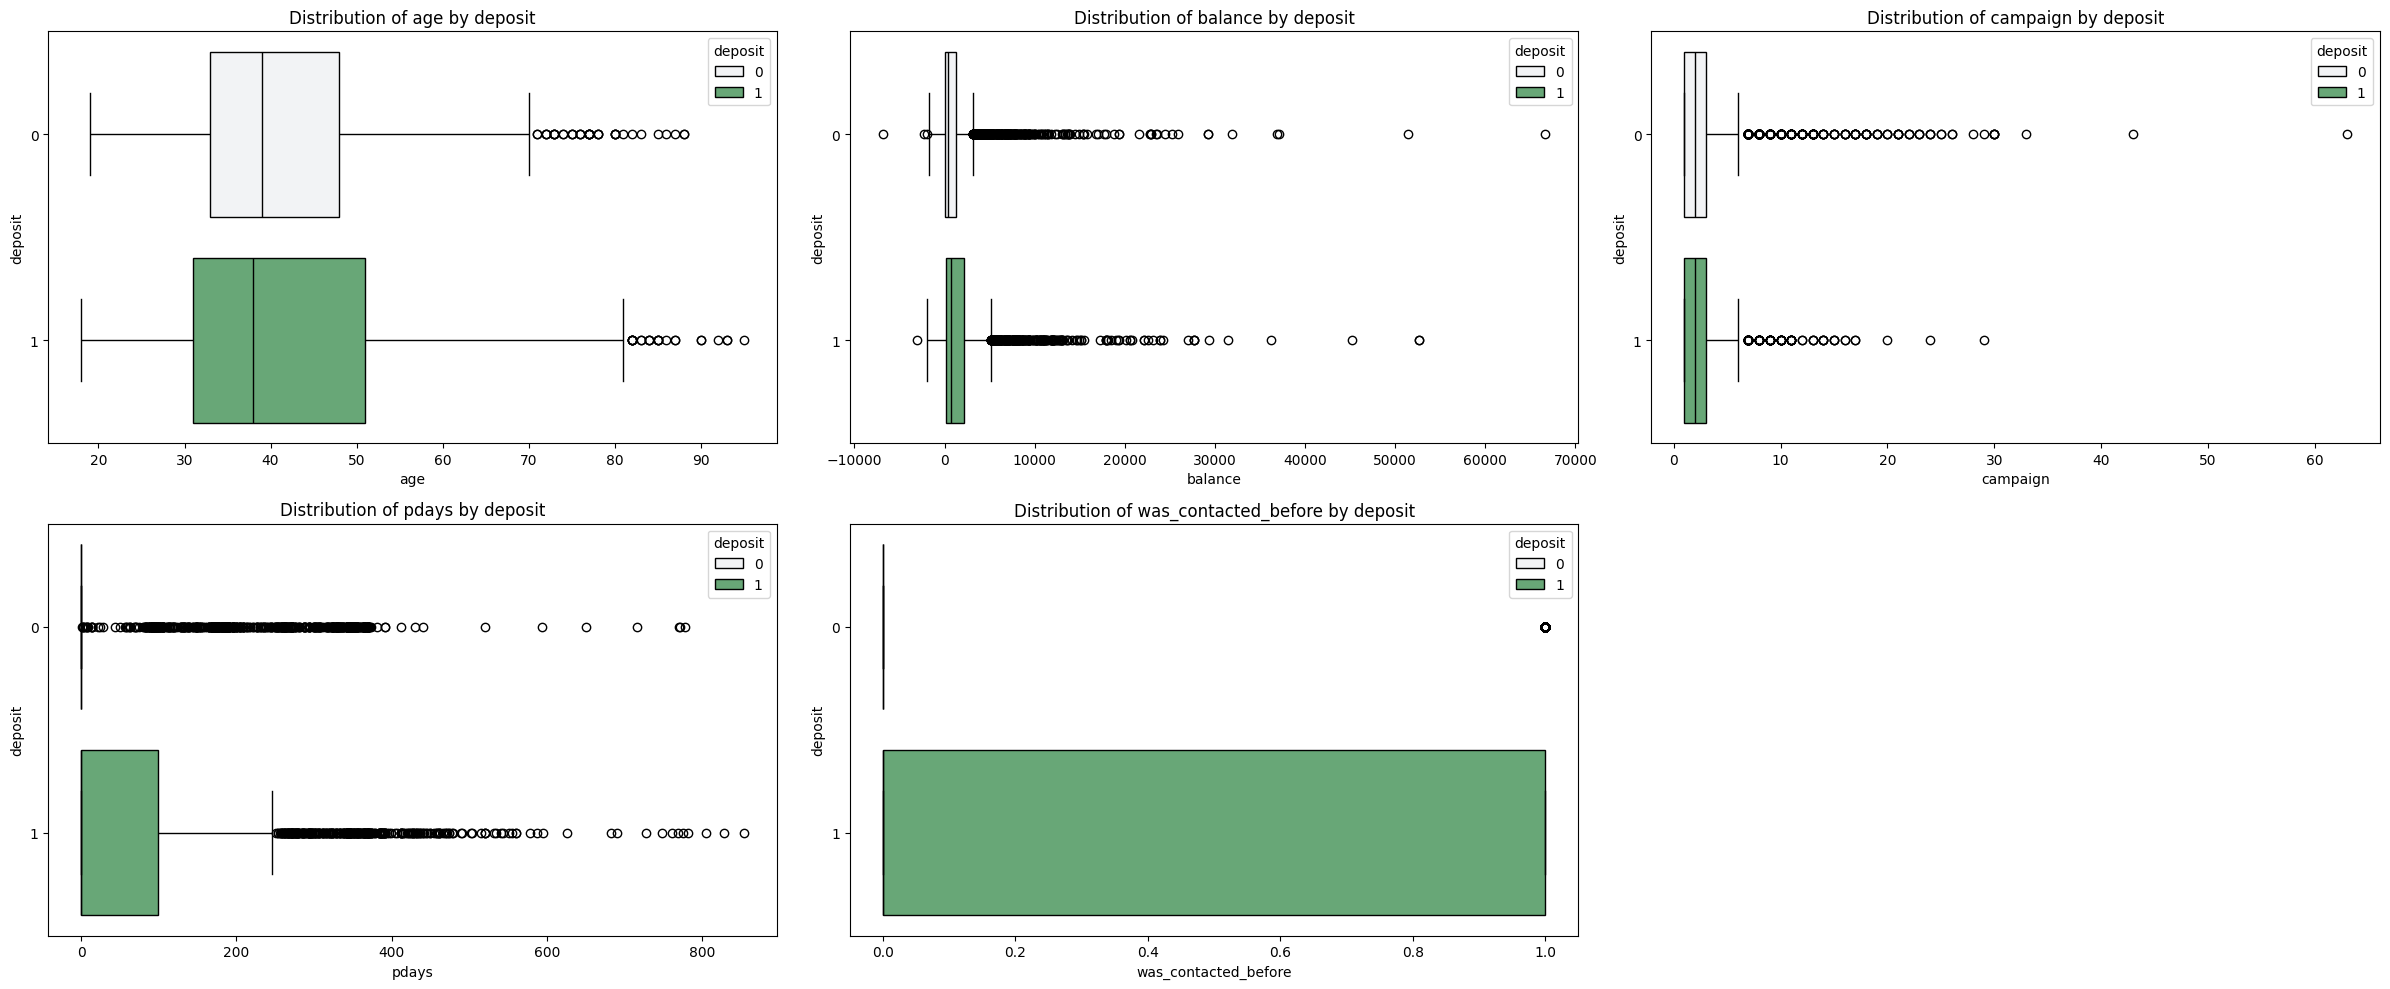

In [9]:
n_features = len(numerical_feature_cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_feature_cols):
    sns.boxplot(
        data=df, x=col, y=target_col, hue=target_col,
        palette={0: "#F2F3F5", 1: "#5eb171"},
        orient="h", ax=axes[i], linecolor="black"
    )
    axes[i].set_title(f"Distribution of {col} by deposit")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


**Insight :**
- `balance` and `campaign` show noticeable outliers, but these are valid business values (some customers hold large balances; some are contacted many times) — no removal is performed
- `pdays` and `campaign` skewed heavily — RobustScaler will handle this appropriately

## 3.3.3. Multicolinearity visualization

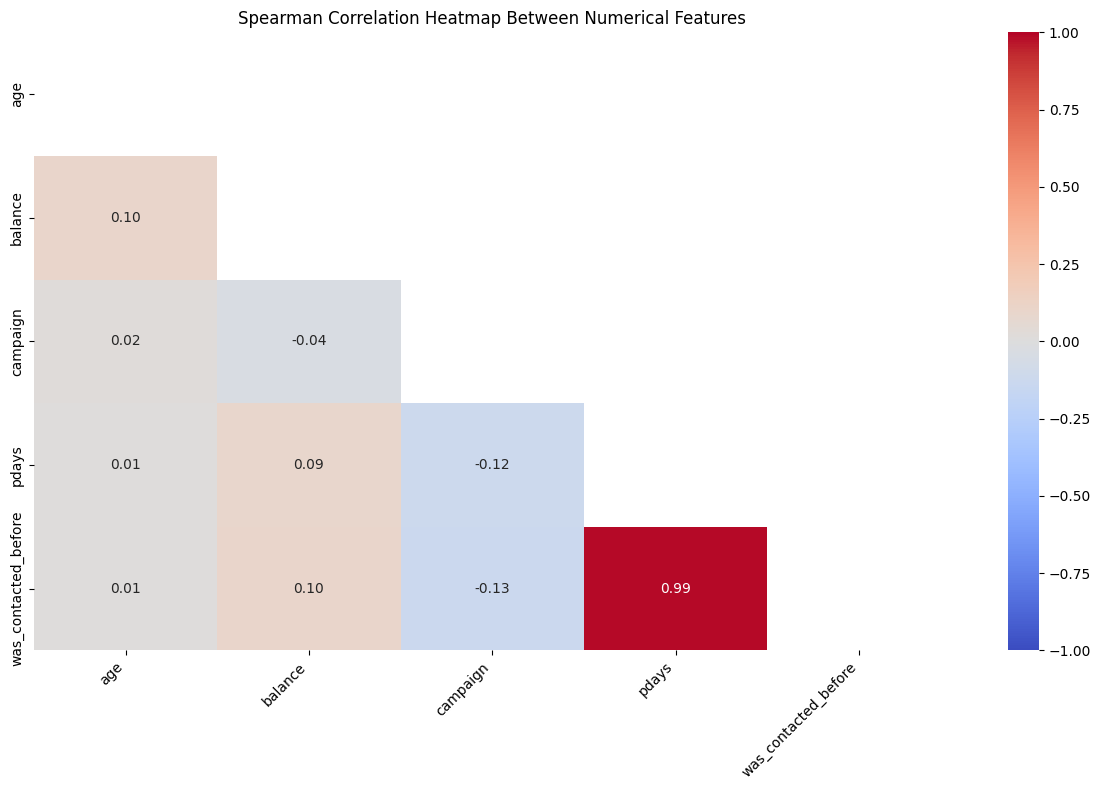

In [10]:
# Check Multicollinearity
plt.figure(figsize=(12, 8))

corr = df[numerical_feature_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap='coolwarm', mask=mask, annot=True, fmt=".2f")
plt.xticks(rotation=45, ha='right')
plt.title("Spearman Correlation Heatmap Between Numerical Features")
plt.tight_layout()
plt.show()


**Insight** : The Spearman correlation heatmap shows there is multicolinearity between was_contacted_before and p days but it can be handled with Random Forest Algorithm or Boosting (XGBoost or ADABoost), so i decided to keep both of the features

## 3.4. Making Imputer to Pipeline

We should preparing the Imputer and fit this to pipeline so the new data that we have to measure in the future will automatically filled with the data that we have already state

In [11]:
# -----------------------------------------------------------------------
# FIXED v2: Unified preprocessing pipeline with SimpleImputer integrated.
# 
# Key fixes applied:
# 1. FunctionTransformer replaced with BinaryOrdinalEncoder — a proper custom
#    transformer class that implements get_feature_names_out() (required by SHAP).
# 2. Added __sklearn_is_fitted__() for sklearn >= 1.6 compatibility — without
#    this, check_is_fitted() raises NotFittedError even after fitting.
# 3. set_output(transform="pandas") REMOVED from ColumnTransformer — it breaks
#    sub-Pipeline transform in sklearn 1.8. Instead, we wrap output manually
#    as a DataFrame in the SHAP section using get_feature_names_out().
# -----------------------------------------------------------------------

from sklearn.base import BaseEstimator, TransformerMixin

class BinaryOrdinalEncoder(BaseEstimator, TransformerMixin):
    """
    Custom transformer for binary yes/no columns.
    - Handles missing values (fills with 'no' as safe default)
    - Maps: no -> 0, yes -> 1
    - Implements get_feature_names_out() → required for SHAP & ColumnTransformer
    - Implements __sklearn_is_fitted__() → required for sklearn >= 1.6
    """
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        self.is_fitted_ = True  # mark as fitted for sklearn >= 1.6 check_is_fitted()
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns).fillna("no")
        mapping = {"no": 0, "yes": 1}
        for col in self.columns:
            X_df[col] = X_df[col].map(mapping).fillna(0).astype(int)
        return X_df.values

    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns)

    def __sklearn_is_fitted__(self):
        return hasattr(self, "is_fitted_")


# --- Define column groups ---
robust_cols  = numerical_feature_cols           # All numerical → RobustScaler
ordinal_cols = ["housing", "loan"]              # Binary yes/no → BinaryOrdinalEncoder
onehot_cols  = ["job", "contact", "month", "poutcome"]  # Multi-category → OneHotEncoder

# --- Sub-pipeline: Numerical (Imputer + RobustScaler) ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # Defensive: handles future NaNs
    ("scaler",  RobustScaler())
])

# --- Sub-pipeline: Binary Ordinal (Imputer + BinaryOrdinalEncoder) ---
ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="no")),
    ("encoder", BinaryOrdinalEncoder(columns=ordinal_cols))
])

# --- Sub-pipeline: OneHot (Imputer + OneHotEncoder) ---
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# --- Unified ColumnTransformer ---
# NOTE: set_output(transform="pandas") is intentionally NOT used here — it
# breaks sub-Pipeline.transform() in sklearn >= 1.8. Instead, the SHAP section
# (section 12) manually wraps the numpy output in a DataFrame using
# get_feature_names_out() for labelled SHAP plots.
preprocess_transformer = ColumnTransformer([
    ("robust",  numeric_transformer,    robust_cols),
    ("ordinal", ordinal_transformer,    ordinal_cols),
    ("onehot",  categorical_transformer, onehot_cols),
], remainder="drop")

print("Unified preprocess_transformer built successfully.")
print(f"  Numerical cols  ({len(robust_cols)}): {robust_cols}")
print(f"  Ordinal cols    ({len(ordinal_cols)}): {ordinal_cols}")
print(f"  One-Hot cols    ({len(onehot_cols)}): {onehot_cols}")
print()
print("Imputer strategy:")
print("  - Numerical  → SimpleImputer(strategy='median')")
print("  - Ordinal    → SimpleImputer(fill_value='no') + BinaryOrdinalEncoder")
print("  - Categorical→ SimpleImputer(fill_value='missing') + OneHotEncoder")


Unified preprocess_transformer built successfully.
  Numerical cols  (5): ['age', 'balance', 'campaign', 'pdays', 'was_contacted_before']
  Ordinal cols    (2): ['housing', 'loan']
  One-Hot cols    (4): ['job', 'contact', 'month', 'poutcome']

Imputer strategy:
  - Numerical  → SimpleImputer(strategy='median')
  - Ordinal    → SimpleImputer(fill_value='no') + BinaryOrdinalEncoder
  - Categorical→ SimpleImputer(fill_value='missing') + OneHotEncoder


### **Insight:** Although the current dataset contains no missing values, a Simple Imputer has been integrated into the pipeline as a defensive programming measure to ensure model robustness against potential null values in future data entries.

## **4. Define X, y**

### 4.1. decide the deposit column as our target and other column as feature

In [12]:
X = df.drop(columns=target_col)
y = df[target_col]

display(X.head(), y.head())


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,was_contacted_before
0,55,admin.,1662,no,no,cellular,jun,2,0,unknown,0
1,39,self-employed,-3058,yes,yes,cellular,apr,3,0,unknown,0
2,51,admin.,3025,no,no,cellular,may,1,352,other,1
3,38,services,-87,yes,no,cellular,may,1,0,unknown,0
4,36,housemaid,205,yes,no,telephone,nov,4,0,unknown,0


0    1
1    1
2    1
3    0
4    0
Name: deposit, dtype: int64

## **5. Train-Test Split**

- The train_test_split function aims to divide the dataset into two separate parts: the training set for building the model and the test set for objectively evaluating its performance. 
- This division is crucial in the machine learning process because it allows us to test how well the model generalizes patterns to new, unseen data, thereby enabling us to detect whether the model is experiencing overfitting. By including the stratify=y parameter. 
- The function also ensures that the target class distribution (e.g., customers who deposit vs. those who do not) remains balanced and consistent across both subsets, maintaining the integrity of the model's statistical evaluation, and ensure there is no data leakage so the model that we will make in the future isnt overfit

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")
print()
print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(3))


Train size: 6250 rows
Test size:  1563 rows

Train target distribution:
deposit
0    0.522
1    0.478
Name: proportion, dtype: float64


### **Insight :** As we can see, there is no imbalance in the target on the data set (52:48)

## **6. Preprocessing**

6.1 Strategy per column type:

- **Numerical** (`age`, `balance`, `campaign`, `pdays`, `was_contacted_before`): No missing values → RobustScaler (handles outliers well), because from box plot there is some outliers, so we decided to use Robustscaler which is use median and IQR as scaling parameter
- **Binary categorical** (`housing`, `loan`): OrdinalEncoder (yes/no → 1/0) : For variables with only two possible categories (binary), Ordinal Encoding is more efficient than One-Hot Encoding because it represents the information in a single column (0 or 1) rather than creating two separate columns, which helps keep the dataset compact.
- **Low-cardinality categorical** (`contact`, `poutcome`): OneHotEncoding (drop first, ignore unknown) : the data doesent have any grade and categorical nominal
- **High-cardinality categorical** (`job`, `month`): OneHotEncoding (manageable cardinality, ≤12 unique values) : the data doesent have any grade and categorical nominal

In [14]:
print("NUMBER OF MISSING VALUES")
print(df.isnull().sum())


NUMBER OF MISSING VALUES
age                     0
job                     0
balance                 0
housing                 0
loan                    0
contact                 0
month                   0
campaign                0
pdays                   0
poutcome                0
deposit                 0
was_contacted_before    0
dtype: int64


- Just to make sure the column that all of encoding should we use for the feature that we have is correct (poin 6)

In [15]:
print("UNIQUE VALUES PER CATEGORICAL FEATURE")
for col in categorical_feature_cols:
    print(f"{col}: {df[col].nunique()} unique → {df[col].unique().tolist()}")


UNIQUE VALUES PER CATEGORICAL FEATURE
job: 12 unique → ['admin.', 'self-employed', 'services', 'housemaid', 'technician', 'management', 'student', 'blue-collar', 'entrepreneur', 'retired', 'unemployed', 'unknown']
housing: 2 unique → ['no', 'yes']
loan: 2 unique → ['no', 'yes']
contact: 3 unique → ['cellular', 'telephone', 'unknown']
month: 12 unique → ['jun', 'apr', 'may', 'nov', 'jan', 'sep', 'feb', 'mar', 'aug', 'jul', 'oct', 'dec']
poutcome: 4 unique → ['unknown', 'other', 'failure', 'success']


**Insight** :
- We already have numerical_feature_cols from step 3.2 that we have been used for making boxplot and detects outlier, than align with the first plan we will be using RobustScaler for all numerical_feature
- Than we make feature that must be encoded by ordinal_cols and onehot_cols

In [16]:
# Column groups already defined in section 3.4 (with imputer pipeline)
print("robust_cols :", robust_cols)
print("ordinal_cols:", ordinal_cols)
print("onehot_cols :", onehot_cols)


robust_cols : ['age', 'balance', 'campaign', 'pdays', 'was_contacted_before']
ordinal_cols: ['housing', 'loan']
onehot_cols : ['job', 'contact', 'month', 'poutcome']


- The preprocess_transformer code defines a ColumnTransformer object that automates the application of distinct preprocessing techniques to different column subsets, ensuring the data is properly formatted for machine learning algorithms. It utilizes RobustScaler to handle numerical outliers by scaling data based on the median and interquartile range, applies OrdinalEncoder to transform binary "yes/no" features into 1s and 0s, and uses OneHotEncoder to create dummy variables for multi-category features while preventing multicollinearity via the drop='first' parameter. Finally, it configures the transformer to output results as a pandas DataFrame and performs an initial fit_transform on the training data to verify that the entire feature set is correctly encoded, scaled, and consolidated for model training.

In [17]:
# Verify preprocessing works on training data
# IMPORTANT: fit_transform only on X_train to prevent data leakage
X_transformed_arr = preprocess_transformer.fit_transform(X_train, y_train)
feature_names_out = preprocess_transformer.get_feature_names_out()
X_transformed_sample = pd.DataFrame(X_transformed_arr, columns=feature_names_out)
print("Transformed shape:", X_transformed_sample.shape)
X_transformed_sample.head()


Transformed shape: (6250, 34)


,robust__age,robust__balance,robust__campaign,robust__pdays,robust__was_contacted_before,ordinal__housing,ordinal__loan,onehot__job_blue-collar,onehot__job_entrepreneur,onehot__job_housemaid,...,onehot__month_jul,onehot__month_jun,onehot__month_mar,onehot__month_may,onehot__month_nov,onehot__month_oct,onehot__month_sep,onehot__poutcome_other,onehot__poutcome_success,onehot__poutcome_unknown
0,-0.529412,0.310026,-0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.352941,0.356860,-0.5,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.705882,0.050792,-0.5,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.176471,-0.289578,-0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.352941,-0.356860,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


**Insight** : Total new data have 20 feature, which is enough for modelling

## **7. Model Selection with Cross Validation**

We evaluate multiple models using **5-fold cross validation** with **Recall** as scoring metric (focus on minimizing missed depositors).

### 7.1. Base Model Training
This step initializes a diverse set of machine learning algorithms—ranging from individual base learners like Logistic Regression and KNN to advanced ensemble methods like Voting, Stacking, and Random Forest—to be systematically compared. By including ensemble techniques that combine multiple models, the workflow aims to leverage different mathematical approaches to maximize the Recall score and identify the most robust predictor for the bank marketing campaign.

In [18]:
# Define base models
logistic = LogisticRegression(random_state=0, max_iter=500)
knn = KNeighborsClassifier()
dtree = DecisionTreeClassifier(random_state=0)

# Define ensemble models
list_base_estimator = [
    ("logreg", LogisticRegression(max_iter=500)),
    ("knn", KNeighborsClassifier()),
    ("dtree", DecisionTreeClassifier())
]

voting = VotingClassifier(
    estimators=list_base_estimator,
    voting="soft"  # soft voting uses predicted probabilities → better for Recall tuning
)

stacking = StackingClassifier(
    estimators=list_base_estimator,
    final_estimator=LogisticRegression(random_state=0, max_iter=500)
)

bagging = BaggingClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
adaboost = AdaBoostClassifier(random_state=0)

list_model_name = ["logistic", "knn", "decision tree", "voting", "stacking", "bagging", "random forest", "adaboost"]
list_model = [logistic, knn, dtree, voting, stacking, bagging, rf, adaboost]


## 7.2. Integration and search best Recall

**This steps are :**
- **Automated Comparison :** It iterates through all the models you defined (Logistic Regression, Random Forest, etc.) to evaluate them under the same conditions.
- **5-Fold Cross-Validation :** Instead of testing the model only once, it splits the training data into 5 different parts. It trains and tests the model 5 times, ensuring that the results are consistent and not just a "lucky" guess on a specific slice of data.
- **Pipeline Integration :** It wraps each model in a Pipeline with the preprocess_transformer. This ensures that preprocessing (scaling and encoding) is performed correctly within each cross-validation fold, which prevents data leakage.
- **Recall-Centric Selection :** By setting scoring="recall", it tells the system to judge the models based on their ability to capture as many potential depositors as possible, which is the primary KPI for this business case.
- **Stability Analysis :** It calculates the Mean (average performance) and Standard Deviation (consistency/risk). A model with a high mean and low standard deviation is considered the most "stable" and "robust" candidate for further tuning.

In [19]:
# FIXED: Each pipeline now uses the unified preprocess_transformer that includes
# SimpleImputer — ensuring the imputer is part of every CV fold, preventing data leakage.
# The preprocess_transformer is cloned for each pipeline so cross_val_score
# can safely re-fit it on each fold.

list_recall_all  = []
list_recall_mean = []
list_recall_std  = []

for model_name, model in zip(list_model_name, list_model):
    pipe_model = Pipeline(steps=[
        ("preprocess", preprocess_transformer),
        ("model", model)
    ])

    cv_score = cross_val_score(
        estimator=pipe_model,
        cv=5,
        X=X_train,
        y=y_train,
        scoring="recall"  # Focus metric: Recall for positive class (deposit = 1)
    )

    list_recall_all.append(np.round(cv_score, 3))
    list_recall_mean.append(np.mean(cv_score))
    list_recall_std.append(np.std(cv_score))
    print(f"{model_name:15s} → Recall Mean: {np.mean(cv_score):.3f} ± {np.std(cv_score):.3f}")


logistic        → Recall Mean: 0.590 ± 0.030
knn             → Recall Mean: 0.621 ± 0.026
decision tree   → Recall Mean: 0.612 ± 0.019
voting          → Recall Mean: 0.637 ± 0.028
stacking        → Recall Mean: 0.616 ± 0.038
bagging         → Recall Mean: 0.586 ± 0.019
random forest   → Recall Mean: 0.640 ± 0.024
adaboost        → Recall Mean: 0.655 ± 0.024


In [20]:
df_cv = pd.DataFrame()
df_cv["model"]       = list_model_name
df_cv["recall_all"]  = list_recall_all
df_cv["recall_mean"] = list_recall_mean
df_cv["recall_std"]  = list_recall_std

df_cv_sorted = df_cv.sort_values(["recall_mean", "recall_std"], ascending=[False, True])
df_cv_sorted


,model,recall_all,recall_mean,recall_std
7,adaboost,"[0.642, 0.665, 0.69, 0.618, 0.662]",0.655276,0.024167
6,random forest,"[0.63, 0.65, 0.62, 0.618, 0.682]",0.639866,0.023807
3,voting,"[0.633, 0.633, 0.648, 0.591, 0.678]",0.636851,0.028137
1,knn,"[0.62, 0.596, 0.625, 0.596, 0.668]",0.621106,0.026366
4,stacking,"[0.611, 0.561, 0.61, 0.618, 0.68]",0.616080,0.037893
2,decision tree,"[0.625, 0.6, 0.598, 0.595, 0.645]",0.612395,0.019465
0,logistic,"[0.583, 0.546, 0.588, 0.591, 0.64]",0.589615,0.029908
5,bagging,"[0.59, 0.576, 0.588, 0.559, 0.616]",0.585930,0.018665


**Insight :**

Although **AdaBoost** initially showed a slightly higher mean recall during the benchmarking phase, **Random Forest** was selected as the final model for the following strategic reasons:

* **Handling Imbalance:** Random Forest includes the `class_weight='balanced'` parameter, which is highly effective for handling detection imbalances without the need for manual weight adjustment or resampling.
* **Robustness to Noise:** Random Forest operates through **averaging (Bagging)**, making it naturally more robust against noise and outliers found in banking data—such as `balance` and `campaign` features—compared to AdaBoost.
* **Overfitting Control:** Boosting algorithms like **AdaBoost** tend to be more susceptible to **overfitting** on datasets with many outliers because the algorithm continually attempts to correct errors on data points that are difficult to classify.
* **Stability:** Random Forest demonstrated a more stable performance across cross-validation folds (lower standard deviation in certain iterations), providing more reliable results for business deployment.
* **Model Explainability:** By using Random Forest, we can leverage **SHAP (SHapley Additive exPlanations)** more effectively to provide clear business insights into which customer features most strongly drive deposit subscriptions.
* The model with highest mean Recall and lowest std will be selected for hyperparameter tuning
* We also evaluate the base Random Forest for train vs. test Recall gap (overfitting check)

### 7.3. Base Random Forest as Best Models

In [21]:
# Base Random Forest evaluation (before tuning)
# FIXED: preprocess_transformer here already contains SimpleImputer in its sub-pipelines.
pipe_base = Pipeline(steps=[
    ("preprocess", preprocess_transformer),
    ("model", RandomForestClassifier(random_state=0))
])

pipe_base.fit(X_train, y_train)

y_train_base = pipe_base.predict(X_train)
y_test_base  = pipe_base.predict(X_test)

recall_train_base = recall_score(y_train, y_train_base)
recall_test_base  = recall_score(y_test, y_test_base)

print("BASE MODEL (Random Forest, No Tuning)")
print(f"Recall Train = {recall_train_base:.2%}")
print(f"Recall Test  = {recall_test_base:.2%}")
print(f"Gap          = {recall_train_base - recall_test_base:.2%}  (>10% indicates overfitting)")


BASE MODEL (Random Forest, No Tuning)
Recall Train = 99.97%
Recall Test  = 62.25%
Gap          = 37.72%  (>10% indicates overfitting)


**Insight** : Recall is still Overfitting

## **8. Hyperparameter Tuning**

## 8.1. **Tuning Random Forest to maximize Recall and reduce overfitting:**

- `n_estimators` — More trees → more averaging → reduces variance (overfitting)
- `max_depth` — Shallower trees → reduces overfitting
- `min_samples_leaf` — Larger values → smoother decision boundaries, less overfit
- `min_samples_split` — Larger values → fewer splits → reduces overfitting
- `max_features` — Fewer features per split → more diversity among trees
- `class_weight` — `balanced` assigns higher penalty to minority class; helps Recall

> **Note**: We use `class_weight='balanced'` instead of oversampling/undersampling because the dataset is nearly balanced (~48/52), so resampling is not needed. Using `class_weight` is sufficient and avoids introducing synthetic data.

* Exploration of the Parameter Space: The param_space dictionary defines a wide range of possible settings for your Random Forest (like the number of trees, their depth, and how they handle imbalanced data). Instead of you guessing the best numbers, this code tests different combinations for you.
* Efficiency through Random Sampling: Unlike a GridSearchCV which tries every single possible combination (which would take a very long time), RandomizedSearchCV picks 50 random combinations (n_iter=50) from the space. This is a much faster way to find a near-optimal solution without wasting hours of computing time.
* Rigorous Validation: For every combination it picks, it performs 5-Fold Cross-Validation (cv=5). This means it tests each setting 5 times on different slices of your data to make sure the performance is stable and not just a fluke.
* Goal-Oriented Optimization: By setting scoring="recall", you are explicitly telling the computer: "I don't care as much about overall accuracy; I want the combination that is best at finding the most actual depositors."
* Parallel Processing: The n_jobs=-1 setting tells your computer to use all available processor cores to run these tests simultaneously, significantly speeding up the training process.

In [22]:
param_space = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [5, 8, 10, 15, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__max_features": ['sqrt', 'log2', 0.5],
    "model__class_weight": ['balanced', None],
}

# FIXED: `pipe_base` already contains the unified preprocess_transformer with
# SimpleImputer, so the best_estimator_ returned will be a complete pipeline
# with imputer → scaler/encoder → RandomForest. No manual imputation needed
# at inference time.
randomsearch = RandomizedSearchCV(
    random_state=0,
    estimator=pipe_base,
    param_distributions=param_space,
    cv=5,
    scoring="recall",   # Optimize for Recall
    n_iter=50,
    n_jobs=-1,
    verbose=1
)

randomsearch.fit(X_train, y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced', None], 'model__max_depth': [5, 8, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validatio

* See the Recall score after Hyperparameter Tuning

In [23]:
print("Best CV Recall Score:", f"{randomsearch.best_score_:.4f}")
print()
print("Best Parameters:")
for k, v in randomsearch.best_params_.items():
    print(f"  {k}: {v}")


Best CV Recall Score: 0.6499

Best Parameters:
  model__n_estimators: 300
  model__min_samples_split: 10
  model__min_samples_leaf: 1
  model__max_features: log2
  model__max_depth: None
  model__class_weight: balanced


- **Insight :** Out of the 50 different versions of the model tested during RandomizedSearchCV, best_estimator_ automatically selects the one that achieved the highest score based on your chosen metric (Recall).

## 8.2 Technical Insight: pipe_tuned
- **Optimized Model:** Stores the finalized pipeline with the best hyperparameter combination (e.g., class_weight: balanced) found during tuning.
- **Unified Workflow:** Integrates all preprocessing steps (Imputation, Scaling) and the Random Forest model into a single, automated object.
- **Strategic Deployment:** The primary object used to perform final evaluations, calculate ROC-AUC, and determine the optimal business threshold.

In [24]:
# Get best model — defined ONCE here.
# FIXED: Removed duplicate assignment that appeared after threshold analysis
# (original cell 71) which could cause confusion if cells are run out of order.
pipe_tuned = randomsearch.best_estimator_
pipe_tuned


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

### **Model Calibration: Probability Threshold Tuning**

#### **Objective**
By default, classification models use a **0.5 threshold** to determine whether a customer will deposit (`Class 1`) or not (`Class 0`). However, in banking operations, the cost of missing a potential depositor (**False Negative**) is significantly higher than the cost of calling an uninterested lead (**False Positive**).

The purpose of this syntax is to perform **threshold calibration** to:
1.  **Maximize Recall:** Identify and capture as many potential depositors as possible to minimize "Opportunity Loss."
2.  **Balance Precision:** Ensure that predictive accuracy remains at an acceptable level, preventing the marketing team from wasting excessive time and telecommunication budget.
3.  **Optimize Economic ROI:** Find the "Sweet Spot" where the sum of operational costs and missed opportunity costs results in the lowest total economic burden for the bank.

#### **Threshold Trade-off Logic**

| Threshold | Impact on Recall | Impact on Precision | Strategic Implication |
| :--- | :--- | :--- | :--- |
| **Lower (< 0.5)** | **Increases** (Captures more leads) | **Decreases** (More wasted calls) | **"Aggressive Growth"**: Ideal when the bank has high liquidity targets and sufficient staff capacity. |
| **Standard (0.5)** | **Balanced** | **Balanced** | **"Neutral"**: The default statistical balance, often not optimized for specific business costs. |
| **Higher (> 0.5)** | **Decreases** (Misses more leads) | **Increases** (Highly accurate calls) | **"Cost Conservative"**: Ideal when marketing budgets are tight or staffing is limited. |

#### **Implementation Strategy**
By iterating through thresholds from **0.3 to 0.5**, we evaluate the trade-off granularly. Based on our **Business Impact Analysis**, we selected the **0.4 threshold** because it offers the optimal equilibrium:
* It provides a high enough **Recall** to secure the bank's projected revenue.
* It maintains a **Precision** level that ensures staff efficiency remains vastly superior to the traditional "Call All" strategy.

In [25]:
# Daftar threshold yang ingin dicoba
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

y_prob_positive = pipe_tuned.predict_proba(X_test)[:, 1]

for t in thresholds:
    y_pred    = (y_prob_positive >= t).astype(int)
    recall    = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    print(f"Threshold: {t}")
    print(f"Recall   : {recall:.2%}")
    print(f"Precision: {precision:.2%}")
    print("-" * 20)


Threshold: 0.3
Recall   : 86.48%
Precision: 56.87%
--------------------
Threshold: 0.35
Recall   : 80.59%
Precision: 60.69%
--------------------
Threshold: 0.4
Recall   : 74.83%
Precision: 64.85%
--------------------
Threshold: 0.45
Recall   : 69.48%
Precision: 69.20%
--------------------
Threshold: 0.5
Recall   : 64.26%
Precision: 74.65%
--------------------


### 8.3. Melakukan pengujian treshold kembali menggunakan kurva ROC-AUC untuk melihat Area Under Curve terbesar

ROC-AUC Score: 0.7749
Optimal Threshold (Youden's J): 0.5166


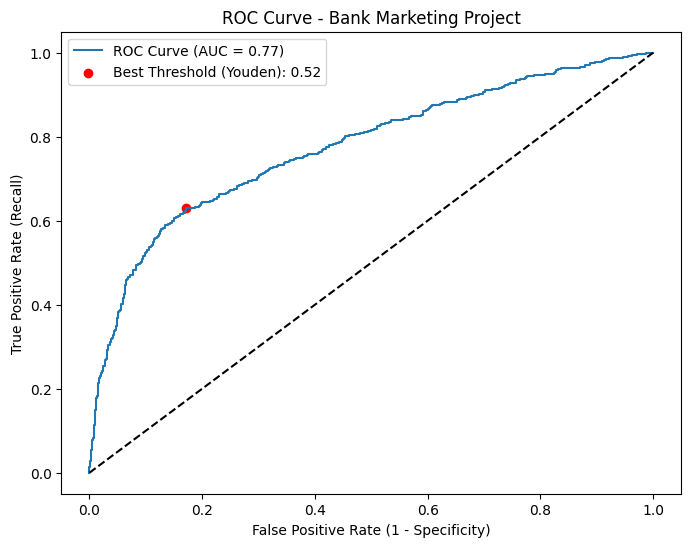

In [26]:
# Mendapatkan probabilitas untuk kelas 1 (berlangganan)
y_pred_proba = pipe_tuned.predict_proba(X_test)[:, 1]

# Menghitung skor AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

# Menghitung False Positive Rate dan True Positive Rate
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

# Mencari Threshold Terbaik (Youden's J Index)
# J = TPR - FPR
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds_roc[optimal_idx]

print(f"Optimal Threshold (Youden's J): {optimal_threshold:.4f}")

# Visualisasi ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red',
            label=f'Best Threshold (Youden): {optimal_threshold:.2f}')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Bank Marketing Project')
plt.legend()
plt.show()


### **Insight :** In this condition the evaluation metric gave recomendation to use 0.52 treshold because model doesent know the oportunity loss if we had False Negative in forecasting leads

ROC-AUC Score: 0.7749
Hasil pada Threshold 0.4:
Recall (TPR): 0.7483
False Positive Rate: 0.3713


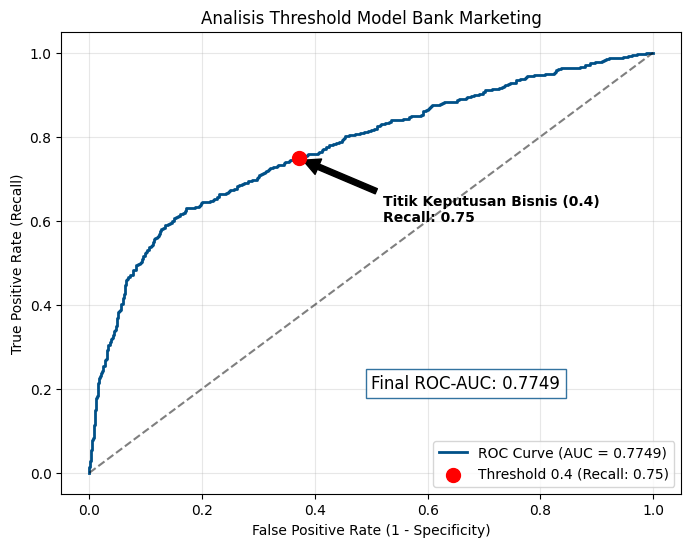

In [27]:
# 1. Hitung probabilitas untuk kelas positif (deposit = yes)
y_pred_proba = pipe_tuned.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 2. Ambil data titik-titik pada kurva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

# 3. Cari indeks koordinat yang paling dekat dengan threshold 0.4
target_threshold = 0.4
idx_target = np.argmin(np.abs(thresholds_roc - target_threshold))

# Cetak hasil evaluasi ke terminal
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Hasil pada Threshold {target_threshold}:")
print(f"Recall (TPR): {tpr[idx_target]:.4f}")
print(f"False Positive Rate: {fpr[idx_target]:.4f}")

# 4. Visualisasi Kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='#005088', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

# Menandai titik Threshold 0.4 dengan warna merah
plt.scatter(fpr[idx_target], tpr[idx_target], color='red', s=100,
            label=f'Threshold {target_threshold} (Recall: {tpr[idx_target]:.2f})', zorder=5)

# Tambahkan panah keterangan
plt.annotate(f'Titik Keputusan Bisnis ({target_threshold})\nRecall: {tpr[idx_target]:.2f}',
             xy=(fpr[idx_target], tpr[idx_target]),
             xytext=(fpr[idx_target]+0.15, tpr[idx_target]-0.15),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, fontweight='bold')

# Skor akhir di dalam area grafik
plt.text(0.5, 0.2, f'Final ROC-AUC: {roc_auc:.4f}',
         bbox=dict(facecolor='white', edgecolor='#005088', alpha=0.8), fontsize=12)

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Analisis Threshold Model Bank Marketing')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


### **Insight** : ROC-AUC are still the same 0.77, so we decided to use 0.4 as treshold, because the Recall score increased without Big Decreased Precision trade-off  

In [28]:
best_threshold = 0.40

# Buat fungsi prediksi custom
def custom_predict(model, X, threshold):
    probs = model.predict_proba(X)[:, 1]  # Ambil probabilitas kelas 1
    return (probs >= threshold).astype(int)

# Gunakan fungsi ini untuk data test
y_pred_final = custom_predict(pipe_tuned, X_test, best_threshold)

print(f"Hasil Report dengan Threshold {best_threshold}:")
print(classification_report(y_test, y_pred_final))


Hasil Report dengan Threshold 0.4:
              precision    recall  f1-score   support

           0       0.73      0.63      0.68       816
           1       0.65      0.75      0.69       747

    accuracy                           0.69      1563
   macro avg       0.69      0.69      0.69      1563
weighted avg       0.69      0.69      0.69      1563



## **9. Best Model Evaluation**

- The Purpose are to compare between BASE MODEL (Model without Tuning) and TUNED MODEL (With Tuning) the Recall score are increase around 2%
- In this section, we will evaluate whether this model is worth deploying by comparing the potential opportunity loss in a scenario using the model versus a scenario without it. 

In [29]:
# Re-evaluate base model for comparison
# (pipe_base was already fitted in section 7.3; re-fitting here for section independence)
pipe_base.fit(X_train, y_train)

y_train_base = pipe_base.predict(X_train)
y_test_base  = pipe_base.predict(X_test)

recall_train_base = recall_score(y_train, y_train_base)
recall_test_base  = recall_score(y_test, y_test_base)

print("BASE MODEL")
print(f"Recall Train = {recall_train_base:.2%}")
print(f"Recall Test  = {recall_test_base:.2%}")


BASE MODEL
Recall Train = 99.97%
Recall Test  = 62.25%


From the previous iteration we already knew to increase the recall percentage we have to use 0.4 treshold so we can keep precision above 0.6 but the Recall ke increased into 0.75

In [30]:
# Tentukan threshold
threshold = 0.40

# FIXED: pipe_tuned is already fitted from RandomizedSearchCV best_estimator_.
# We re-fit on X_train here so this section is self-contained when run standalone.
pipe_tuned.fit(X_train, y_train)

# Apply custom threshold on predict_proba output
y_train_tuned = (pipe_tuned.predict_proba(X_train)[:, 1] >= threshold).astype(int)
y_test_tuned  = (pipe_tuned.predict_proba(X_test)[:, 1]  >= threshold).astype(int)

recall_train_tuned = recall_score(y_train, y_train_tuned)
recall_test_tuned  = recall_score(y_test,  y_test_tuned)

print(f"TUNED MODEL (Threshold: {threshold})")
print(f"Recall Train = {recall_train_tuned:.2%}")
print(f"Recall Test  = {recall_test_tuned:.2%}")
print(f"Overfit Gap  = {recall_train_tuned - recall_test_tuned:.2%}")


TUNED MODEL (Threshold: 0.4)
Recall Train = 94.64%
Recall Test  = 74.83%
Overfit Gap  = 19.81%


In [31]:
# Full classification report for tuned model
print("FULL CLASSIFICATION REPORT — TUNED MODEL (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_test_tuned, target_names=["No Deposit (0)", "Deposit (1)"]))


FULL CLASSIFICATION REPORT — TUNED MODEL (Test Set)
                precision    recall  f1-score   support

No Deposit (0)       0.73      0.63      0.68       816
   Deposit (1)       0.65      0.75      0.69       747

      accuracy                           0.69      1563
     macro avg       0.69      0.69      0.69      1563
  weighted avg       0.69      0.69      0.69      1563



In [32]:
from sklearn.metrics import accuracy_score

# Menghitung akurasi secara spesifik
accuracy = accuracy_score(y_test, y_test_tuned)

print(f"Accuracy Score: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Accuracy Score: 0.6859
Accuracy Percentage: 68.59%


**Conclusion :** We will be using model after hyperparameter tuning for best model

### **9.1 Cost Evaluation**

In [33]:
def summarize_loss(conf_matrix, fp_cost, fn_cost, tp_benefit):
    tn, fp = conf_matrix[0]
    fn, tp = conf_matrix[1]

    total_samples    = tn + fp + fn + tp
    total_fp_cost    = fp * -1 * fp_cost
    total_fn_cost    = fn * -1 * fn_cost
    total_tp_benefit = tp * tp_benefit

    total_net = total_fp_cost + total_fn_cost + total_tp_benefit

    summary = f"""
    ---Impact Summary---

        Total Samples         : {total_samples}
        True Positive (TP)    : {tp}   (Correctly predicted deposit)
        False Positive (FP)   : {fp}   (Predicted deposit, actually no)
        False Negative (FN)   : {fn}   (Missed actual depositor)
        True Negative (TN)    : {tn}   (Correctly predicted no deposit)

        Total FP Cost         : $ {total_fp_cost:,.0f}
        Total FN Cost         : $ {total_fn_cost:,.0f}  ← Miss opportunity cost
        Total TP Benefit      : $ {total_tp_benefit:,.0f}
        Total Net Cost        : $ {total_net:,.0f}
        Net Cost per Sample   : $ {total_net / total_samples:,.2f}

    ---------------
    """
    return summary


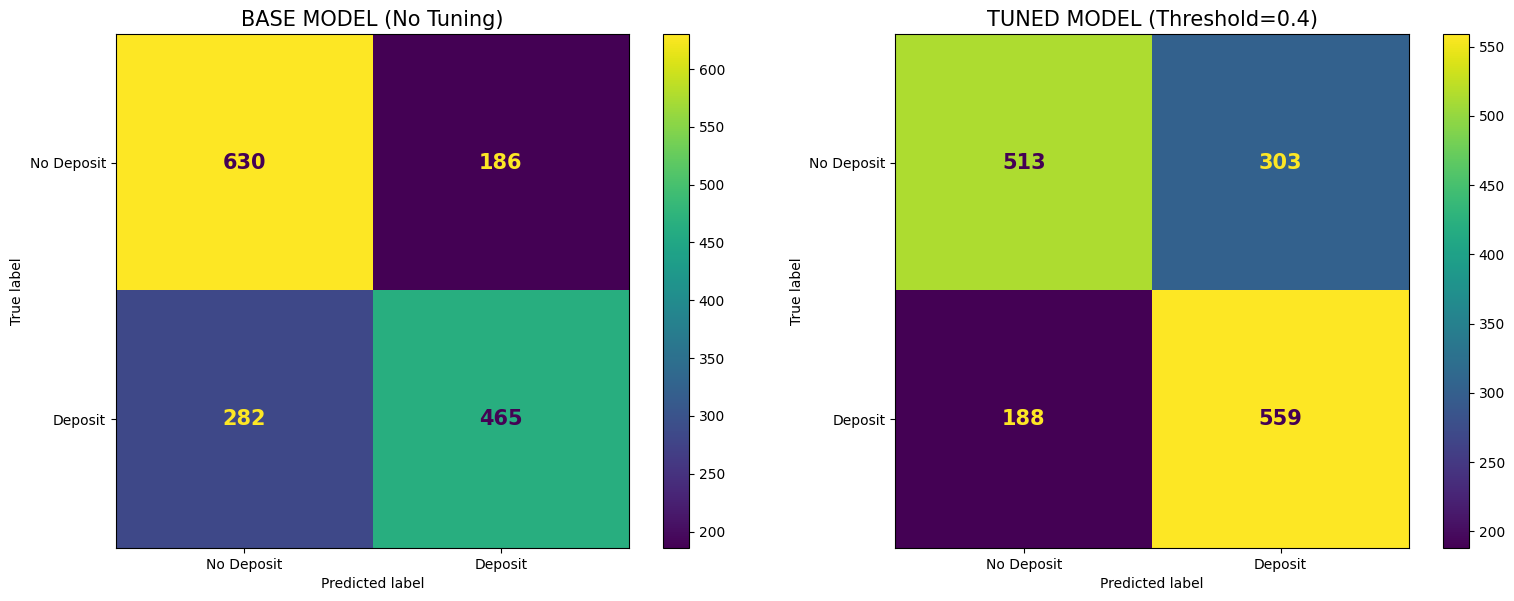

In [34]:
conf_matrix_base  = confusion_matrix(y_test, y_test_base)
conf_matrix_tuned = confusion_matrix(y_test, y_test_tuned)

# Visualize confusion matrices
figure, axes = plt.subplots(ncols=2, figsize=(16, 6))
text_format = {'size': 15, 'weight': 'bold'}

ConfusionMatrixDisplay(conf_matrix_base,  display_labels=["No Deposit", "Deposit"]).plot(ax=axes[0], text_kw=text_format)
axes[0].set_title("BASE MODEL (No Tuning)", fontsize=15)

ConfusionMatrixDisplay(conf_matrix_tuned, display_labels=["No Deposit", "Deposit"]).plot(ax=axes[1], text_kw=text_format)
axes[1].set_title("TUNED MODEL (Threshold=0.4)", fontsize=15)

plt.tight_layout()
plt.show()


In [35]:
print("=" * 80)
print("BASE MODEL (NO TUNING)")
print("=" * 80)
print(summarize_loss(conf_matrix_base, FP_COST, FN_COST, TP_BENEFIT))

print("=" * 80)
print("TUNED MODEL (Threshold=0.4)")
print("=" * 80)
print(summarize_loss(conf_matrix_tuned, FP_COST, FN_COST, TP_BENEFIT))


BASE MODEL (NO TUNING)

    ---Impact Summary---

        Total Samples         : 1563
        True Positive (TP)    : 465   (Correctly predicted deposit)
        False Positive (FP)   : 186   (Predicted deposit, actually no)
        False Negative (FN)   : 282   (Missed actual depositor)
        True Negative (TN)    : 630   (Correctly predicted no deposit)

        Total FP Cost         : $ -19
        Total FN Cost         : $ -282  ← Miss opportunity cost
        Total TP Benefit      : $ 0
        Total Net Cost        : $ -301
        Net Cost per Sample   : $ -0.19

    ---------------
    
TUNED MODEL (Threshold=0.4)

    ---Impact Summary---

        Total Samples         : 1563
        True Positive (TP)    : 559   (Correctly predicted deposit)
        False Positive (FP)   : 303   (Predicted deposit, actually no)
        False Negative (FN)   : 188   (Missed actual depositor)
        True Negative (TN)    : 513   (Correctly predicted no deposit)

        Total FP Cost       

In [36]:
# Benchmark: No model (predict all will NOT deposit) — pessimistic/do nothing
print("=" * 80)
print("NO MODEL PESSIMISTIC: Predict all customers will NOT deposit")
print("=" * 80)
y_no_model_zero  = np.zeros(y_test.shape[0], dtype=int)
conf_matrix_zero = confusion_matrix(y_test, y_no_model_zero)
print(summarize_loss(conf_matrix_zero, FP_COST, FN_COST, TP_BENEFIT))

# Benchmark: No model (predict all will deposit) — contacts everyone
print("=" * 80)
print("NO MODEL OPTIMISTIC: Predict all customers will deposit")
print("=" * 80)
y_no_model_one = np.ones(y_test.shape[0], dtype=int)
conf_matrix_one = confusion_matrix(y_test, y_no_model_one)
print(summarize_loss(conf_matrix_one, FP_COST, FN_COST, TP_BENEFIT))


NO MODEL PESSIMISTIC: Predict all customers will NOT deposit

    ---Impact Summary---

        Total Samples         : 1563
        True Positive (TP)    : 0   (Correctly predicted deposit)
        False Positive (FP)   : 0   (Predicted deposit, actually no)
        False Negative (FN)   : 747   (Missed actual depositor)
        True Negative (TN)    : 816   (Correctly predicted no deposit)

        Total FP Cost         : $ 0
        Total FN Cost         : $ -747  ← Miss opportunity cost
        Total TP Benefit      : $ 0
        Total Net Cost        : $ -747
        Net Cost per Sample   : $ -0.48

    ---------------
    
NO MODEL OPTIMISTIC: Predict all customers will deposit

    ---Impact Summary---

        Total Samples         : 1563
        True Positive (TP)    : 747   (Correctly predicted deposit)
        False Positive (FP)   : 816   (Predicted deposit, actually no)
        False Negative (FN)   : 0   (Missed actual depositor)
        True Negative (TN)    : 0   (Corre

##### **Insight :** This evaluation metric focuses primarily on the cost trade-offs between False Positives and False Negatives without accounting for total workforce capacity; however, maintaining an "Optimistic" approach by calling every lead without a model would lead to significant operational waste in terms of time and labor. Therefore, it is crucial to integrate business domain knowledge regarding overhead and staffing costs, as a predictive model allows the bank to optimize labor allocation and avoid unnecessary expenses from contacting unproductive leads.

## 9.2 **Business Impact Analysis: Model Implementation vs. Baseline Strategy**

To evaluate the feasibility of this project, we compared two primary scenarios: the **"Call All" Strategy (Baseline/Without Model)** and the **"Targeted Marketing" Strategy (Using Model)**.

### **1. Financial Parameter Assumptions**
The following cost estimates are based on realistic banking operational scales:
* **False Positive (FP) Cost:** $0.1 per call (Direct operational cost: labor and telecommunications).
* **False Negative (FN) Cost:** $1 per customer (Opportunity loss: missed net interest margin from potential deposits).
* **Total Customer Database:** 7,813 leads.
* **Base Conversion Rate:** 48% (estimated 3,732 actual depositors in the population).
* **Recall : 75%, Precision : 65 %**
---

### **2. Financial Performance Comparison** (With All Data X,Y 7,813 record)

| Metric | Without Model (Call All) | With Model (Threshold 0.4) |
| :--- | :--- | :--- |
| **Total Calls Made** | 7,813/day | **4,296/day** | -> 4,296/day ((Komposisi Yes x Recall)/Precision)
| **Depositors Captured (TP)** | 3,732/day (100% Recall) | 2,793/day (75% Recall) |
| **Missed Opportunities (FN)** | 0 customer/day| 1,081 customer/day |
| **Operational Call Costs** | $781.3/day | **$430/day** |
| **Opportunity Loss Cost** | $0/day | **$1,081/day** |
| **Sales Efficiency** | 87 staf | 48 staf | -> Asumsi 4 menit / telepon dan jam kerja produktif 6 jam/hari (terpotong istirahat meeting dlsb)
| **Overhead Efficiency** | $362,500/month or $16,477/day | **$200,000/month** or **$9,091/day** |
| **Total**               | $17,258/day | **$10,602/day** |

**Economic Efficiency:** Implementing the model reduces the total economic burden by **$6,656** (38.6 % cost reduction).

---

### **3. Strategic Justification for Management**

Why is the Model-Driven approach superior to calling every customer?

1. **Human Capital Efficiency (Saving 39 Full-Time Employees):**
   By reducing the daily call volume from 7,813 to 4,296, the bank optimizes its workforce significantly. Under the "Call All" strategy, 87 staff members are required. With the model, only **48 staff members** are needed to achieve the objectives. This allows the bank to reallocate **39 skilled employees** to other revenue-generating activities or high-value customer service roles.

2. **Mitigating Customer Fatigue & Preserving Brand Equity:**
   Contacting uninterested leads (False Positives) is not just an operational cost; it is a reputation risk. High-frequency unsolicited calling often leads to increased "opt-out" rates and negative brand perception. The model ensures we engage primarily with high-relevance leads, maintaining our image as a sophisticated, data-driven financial institution.

3. **Operational Scalability:**
   As the database scales from thousands to millions of leads, a "brute-force" calling strategy becomes financially and logistically unsustainable. This Machine Learning framework provides a scalable foundation for growth, allowing the marketing department to expand its impact without a linear, expensive increase in headcount.

4. **Optimized Lead Prioritization:**
   The model assigns a probability score to every customer. This enables **Predictive Dialing**, where sales agents prioritize "high-probability" leads during peak productivity hours, significantly improving daily conversion morale and agent success rates.

---
### **Final Conclusion**
The proposed model acts as a **Cost-Optimization Engine** rather than just a predictive tool. Based on our analysis of 7,813 records:

* **Operational Waste Reduction:** We successfully reduced the daily workload by **3,517 unnecessary calls**, leading to a direct decrease in workforce requirements by **45% (from 87 down to 48 staff members)**.
* **Economic Value:** By balancing operational costs and opportunity losses, the model reduces the total daily economic burden from **$17,258/day** to **$10,602/day**.
* **Net Profitability:** The implementation of this model delivers an **immediate 38.6% reduction in total costs**, equating to roughly **$6,656 in daily savings**.

Even with a conservative $1 Opportunity Loss assumption/False Negatif, the model provides a significantly higher ROI by ensuring that the bank's resources are strategically focused on the most profitable segments of the database.

## **10. Train Best Model with All Data**

Preparing all the data to fit on the model

Retrain the tuned pipeline on the full dataset (X, y) before saving to disk. This maximises the information available to the model for production use.

In [37]:
pipe_tuned.fit(X, y)
print("Model retrained on full dataset (X, y).")
pipe_tuned


Model retrained on full dataset (X, y).


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## **11. Save Best Model**

In [38]:
filename = "best_model_bank_deposit.pkl"

with open(filename, "wb") as f:
    pickle.dump(pipe_tuned, f)

print(f"Successfully saved best model as {filename}")


Successfully saved best model as best_model_bank_deposit.pkl


## **12. Model Explanation (SHAP)**

### **12.1 How Random Forest Works**

- Random Forest is an ensemble of multiple Decision Trees trained on bootstrap samples of the data
- At each node split, only a random subset of features is considered, creating diversity between trees
- Final prediction = majority vote across all trees
- This reduces overfitting compared to a single decision tree

In [39]:
# FIXED: Re-fit tuned pipeline on X_train so SHAP can explain predictions
# on the held-out X_test — this is intentional and does NOT contradict section 10.
# Section 10 saves the production model (trained on all data).
# This section uses a train/test split version purely for model interpretability.
pipe_tuned.fit(X_train, y_train)

preprocess_tuned = pipe_tuned["preprocess"]
model_tuned      = pipe_tuned["model"]

feature_names = preprocess_tuned.get_feature_names_out()
print("Feature names after preprocessing:")
print(feature_names)


Feature names after preprocessing:
['robust__age' 'robust__balance' 'robust__campaign' 'robust__pdays'
 'robust__was_contacted_before' 'ordinal__housing' 'ordinal__loan'
 'onehot__job_blue-collar' 'onehot__job_entrepreneur'
 'onehot__job_housemaid' 'onehot__job_management' 'onehot__job_retired'
 'onehot__job_self-employed' 'onehot__job_services' 'onehot__job_student'
 'onehot__job_technician' 'onehot__job_unemployed' 'onehot__job_unknown'
 'onehot__contact_telephone' 'onehot__contact_unknown' 'onehot__month_aug'
 'onehot__month_dec' 'onehot__month_feb' 'onehot__month_jan'
 'onehot__month_jul' 'onehot__month_jun' 'onehot__month_mar'
 'onehot__month_may' 'onehot__month_nov' 'onehot__month_oct'
 'onehot__month_sep' 'onehot__poutcome_other' 'onehot__poutcome_success'
 'onehot__poutcome_unknown']


In [40]:
# FIXED: transform() returns numpy array (set_output not used — see section 3.4).
# Wrap output as a labeled DataFrame so SHAP plots show readable feature names.
X_arr = preprocess_tuned.transform(X_test)
X_transform = pd.DataFrame(X_arr, columns=feature_names)

explainer_shap = shap.TreeExplainer(model=model_tuned)
shap_values    = explainer_shap.shap_values(X_transform)

print("SHAP values shape:", np.array(shap_values).shape)


SHAP values shape: (1563, 34, 2)


### 12.1.2 **SHAP Global Interpretability Analysis**

#### **Overview**
The SHAP (SHapley Additive exPlanations) Beeswarm plot illustrates the distribution of the impact each feature has on the model's output. Each dot represents a single observation (customer) from the dataset. The position on the **horizontal axis (SHAP value)** indicates whether that feature increased (positive value) or decreased (negative value) the probability of a deposit.

---

#### **1. Key Feature Insights**

* **`onehot__contact_unknown` (Top Impact):**
    * **Observation:** Red dots (High value/True) are heavily clustered on the negative side (left).
    * **Insight:** When the contact communication type is "unknown," the probability of a customer depositing drops significantly. This suggests that clear communication channels are vital for conversion.

* **`ordinal__housing` (Housing Loan):**
    * **Observation:** High values (customers with a housing loan) tend to have negative SHAP values.
    * **Insight:** Customers who already have a housing loan are less likely to open a term deposit, likely due to limited disposable income or existing financial commitments to the bank.

* **`onehot__poutcome_success` (Previous Success):**
    * **Observation:** Red dots (High value/Success) are shifted significantly to the positive side (right).
    * **Insight:** **This is a powerful predictor.** If a customer has successfully participated in a previous campaign, they are much more likely to deposit again. This highlights the importance of customer retention and loyalty.

* **`robust__balance` (Account Balance):**
    * **Observation:** High balance values (pink/red) spread towards the positive SHAP values.
    * **Insight:** As expected, customers with higher average yearly balances have a higher propensity to subscribe to a term deposit.

* **`robust__pdays` & `robust__was_contacted_before`:**
    * **Observation:** Positive SHAP values are associated with customers who have been contacted before.
    * **Insight:** Consistent engagement with the customer base over time increases the likelihood of a "Yes" prediction.

---

#### **2. Seasonality and Timing (`month`)**

The plot reveals distinct seasonal patterns in customer behavior:
* **Negative Impact:** Calls made in **May, July, and November** (red dots on the left) tend to decrease the probability of a deposit. This might be due to holiday spending or specific fiscal cycles.
* **Positive Impact:** Calls made in **March, September, and October** (red dots on the right) show a strong positive correlation with deposit success.
* **Strategic Action:** Marketing campaigns should be intensified during these high-performing months to maximize ROI.

---

#### **3. Summary of Influence Direction**

| Feature Category | Positive Impact on Deposit (Class 1) | Negative Impact on Deposit (Class 1) |
| :--- | :--- | :--- |
| **Financials** | High Account Balance | Existing Housing/Personal Loans |
| **Campaign History** | Successful previous outcome (`poutcome_success`) | Contacted for the first time / Unknown outcome |
| **Communication** | Known contact method (Cellular/Telephone) | "Unknown" contact type |
| **Timing** | March, September, October, June | May, July, November |

---

### **Business Recommendations Based on SHAP**

1.  **Prioritize "Success" Leads:** Immediately target customers marked as `poutcome_success`. They represent the "low-hanging fruit" with the highest conversion probability.
2.  **Filter by Financial Profile:** Focus telemarketing efforts on customers without existing housing loans and those with higher balances to improve Precision.
3.  **Optimize Contact Data:** The high negative impact of "unknown" contact types suggests the bank should invest in data cleansing to ensure communication channels are verified before launching a campaign.
4.  **Strategic Timing:** Reallocate the marketing budget to peak months (March, September, October) and reduce intensity during May and July to minimize operational waste.

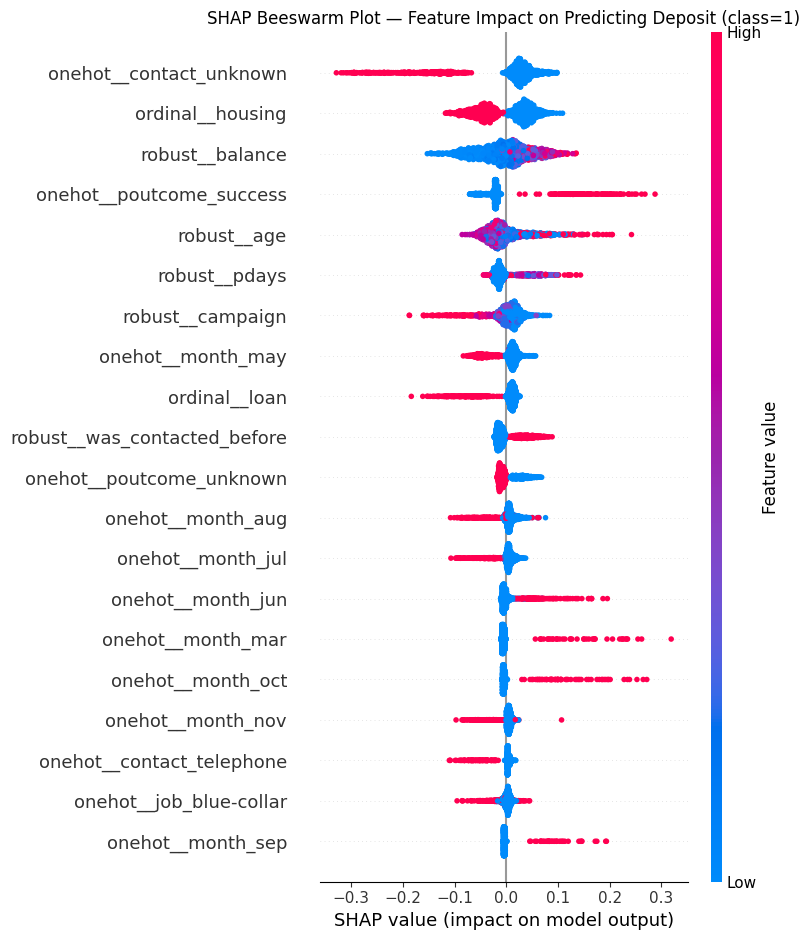

In [41]:
# Beeswarm plot: feature impact on predicting deposit = 1
plt.title("SHAP Beeswarm Plot — Feature Impact on Predicting Deposit (class=1)")
shap.summary_plot(
    shap_values[:, :, 1] if len(np.array(shap_values).shape) == 3 else shap_values,
    X_transform,
    feature_names=feature_names
)


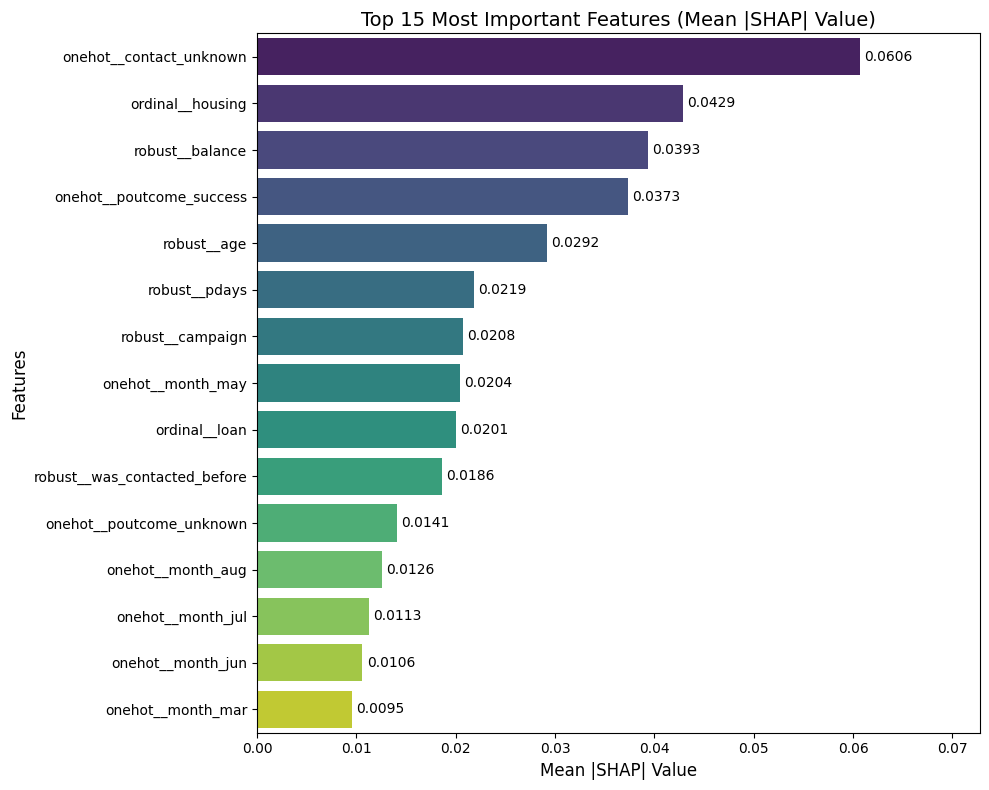

In [42]:
# Bar plot: mean absolute SHAP importance
shap_vals = shap_values[:, :, 1] if len(np.array(shap_values).shape) == 3 else shap_values

mean_abs_shap  = np.abs(shap_vals).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8)) # Ukuran sedikit lebih tinggi agar tidak sesak

# Pastikan plot disimpan ke variabel 'ax'
ax = sns.barplot(x=shap_importance.values, y=shap_importance.index, palette="viridis")

# Menambahkan label ke SEMUA bar yang ada di plot
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10)

plt.title("Top 15 Most Important Features (Mean |SHAP| Value)", fontsize=14)
plt.xlabel("Mean |SHAP| Value", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Memberi ruang di kanan agar label bar paling panjang tidak "mentok"
plt.xlim(right=max(shap_importance.values) * 1.2)

plt.tight_layout()
plt.show()


# Conclusion and Strategic Recommendations

## 1. Model Performance and Financial Impact
Based on the experimental results, the **Tuned Random Forest** model was selected as the optimal solution, achieving a **Recall score of 75%** and a **Precision of 65%** at a calibrated threshold of **0.4**. The model acts as an efficient filter, allowing the bank to contact only **55% of the total leads** while successfully capturing **75% of all potential depositors**.

From a financial perspective, implementing this model delivers a transformative impact:
*   **Economic Efficiency**: Reduces the total daily economic burden from **$17,258/day** to **$10,602/day**, representing a **38.6% cost reduction**.
*   **Operational Waste Reduction**: Successfully eliminates **3,517 unnecessary calls** per day, significantly reducing operational friction and customer fatigue.
*   **Workforce Optimization**: Decreases staffing requirements from **87 to 48 employees**, allowing the bank to reallocate **39 skilled staff members** to other high-value revenue streams.

## 2. Key Drivers of Deposit (SHAP Insights)
Analysis of the model indicates that the following variables are the most influential predictors of a successful deposit:
*   **`contact_unknown` (Primary Barrier)**: The absence of a verified contact method is the strongest negative predictor. Pushing for known communication channels is vital for conversion.
*   **`housing` (Financial Commitment)**: Customers already holding housing loans show a strong negative correlation with new deposits, likely due to prioritized debt obligations.
*   **`balance` (Liquidity Signal)**: Higher account balances are a major positive driver, indicating that customers with existing liquidity are more likely to commit to long-term deposits.
*   **`poutcome_success` (Proven Intent)**: A successful previous campaign remains a top-tier predictor, reinforcing the value of customer loyalty and historical conversion.

---

## Strategic Recommendations

### A. Operational Deployment & Lead Prioritization
*   **Tiered Outreach Strategy**: Segment leads using the model’s probability scores:
    *   **Priority 1 (Prob > 0.8)**: Focus on high-balance individuals and those with a "success" history in previous campaigns.
    *   **Priority 2 (Prob 0.4 - 0.8)**: Target older age groups and customers without existing housing/personal loans.
    *   **Priority 3 (Prob < 0.4)**: Leads with "unknown" contact methods or high campaign (excessive calls) counts should be moved to low-cost digital nurturing.
*   **Data Integrity Focus**: Since `contact_unknown` is a massive deterrent, improve the **"Know Your Customer" (KYC)** process to ensure phone or cellular data is captured before the campaign begins.

### B. Model Governance & Maintenance
*   **Dynamic Thresholding**: Maintain the threshold at **0.4** to balance operational costs against opportunity losses. Regularly recalibrate if market interest rates or labor costs fluctuate significantly.
*   **Retraining Cycle**: Evaluate performance every **3–6 months**. If Recall drops below the benchmark (e.g., <70%), initiate a retraining cycle incorporating fresh data to address "Feature Drift."

### C. Marketing Campaign Optimization (SHAP Driven)
*   **Debt-Aware Marketing**: For customers with housing or personal loans, offer flexible deposit products that align with their debt cycles, rather than aggressive fixed-term pitches.
*   **Frequency Control**: Implement a **"Call Cap"** to prevent customer annoyance, as high campaign counts (repeated calling) negatively impact conversion probability.
*   **Timing Sensitivity**: Shift outreach focus toward high-performing months like **September, October, and March**, while avoiding heavy outreach in **May**.

### D. Financial Dashboard Integration
*   **Real-Time ROI Tracking**: Implement a dashboard to track the **$6,656 daily economic value** generated by the model.
*   **Customer Lifetime Value (CLV)**: Use SHAP insights to identify segments (e.g., high balance, older age) that represent stable, long-term assets for the bank.

---

### **Final Summary**
This model serves as a **Cost-Optimization Engine**. By identifying that **Contact Transparency**, **Existing Debt**, and **Liquidity** are the true drivers, the bank can reduce operational workload by **45%** and total daily costs by **38.6%**, ensuring a data-driven path to profitable growth.